In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt


In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

X, y = X.values, y.astype(int).values

In [3]:
X = ((X/255.) - 0.5) * 2 # scale inputs between -1 and 1

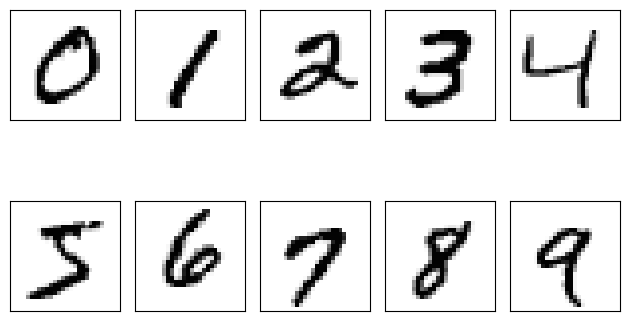

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)

ax = ax.flatten()

for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=10000, random_state=123, stratify=y)


In [7]:
print(X_temp.shape, y_temp.shape)

(60000, 784) (60000,)


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)

In [9]:
from neuralnet import (NeuralNetMLP,
                        minibatch_generator,
                          num_epochs,
                           mse_loss,
                            accuracy,
                            train,
                             compute_mse_and_acc )

In [10]:
model = NeuralNetMLP(num_features=28*28, num_hidden=50, num_classes=10)

In [11]:
model.weight_out.shape

(10, 50)

In [12]:
for i in range(num_epochs):
    minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size=100)

    for X_train_mini, y_train_mini in minibatch_gen:
        break
    break
print(X_train_mini.shape, y_train_mini.shape)

(100, 784) (100,)


In [13]:
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)
print(f'Initial validation mse: {mse:.1f}')

Initial validation mse: 0.3


In [14]:
predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)

print(f'Initial validation accuracy: {acc*100:.1f}')

Initial validation accuracy: 9.4


In [15]:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)

print(f'Initial validation mse: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation mse: 0.3
Initial validation accuracy: 9.4%


In [16]:
np.random.seed(123)
epoch_loss, epoch_train_acc, epoch_valid_acc = train(model, X_train,
                                                     
                                                     y_train, X_valid, y_valid,
                                                     num_epochs=50, learning_rate=0.1)

Epoch 001/050| Train MSE: 0.05| Train Acc: 76.15| Validation ACC: 75.98
Epoch 002/050| Train MSE: 0.03| Train Acc: 85.45| Validation ACC: 85.04
Epoch 003/050| Train MSE: 0.02| Train Acc: 87.82| Validation ACC: 87.60
Epoch 004/050| Train MSE: 0.02| Train Acc: 89.36| Validation ACC: 89.28
Epoch 005/050| Train MSE: 0.02| Train Acc: 90.21| Validation ACC: 90.04
Epoch 006/050| Train MSE: 0.02| Train Acc: 90.67| Validation ACC: 90.54
Epoch 007/050| Train MSE: 0.02| Train Acc: 91.12| Validation ACC: 90.82
Epoch 008/050| Train MSE: 0.02| Train Acc: 91.43| Validation ACC: 91.26
Epoch 009/050| Train MSE: 0.01| Train Acc: 91.84| Validation ACC: 91.50
Epoch 010/050| Train MSE: 0.01| Train Acc: 92.04| Validation ACC: 91.84
Epoch 011/050| Train MSE: 0.01| Train Acc: 92.30| Validation ACC: 92.08
Epoch 012/050| Train MSE: 0.01| Train Acc: 92.51| Validation ACC: 92.24
Epoch 013/050| Train MSE: 0.01| Train Acc: 92.65| Validation ACC: 92.30
Epoch 014/050| Train MSE: 0.01| Train Acc: 92.80| Validation ACC

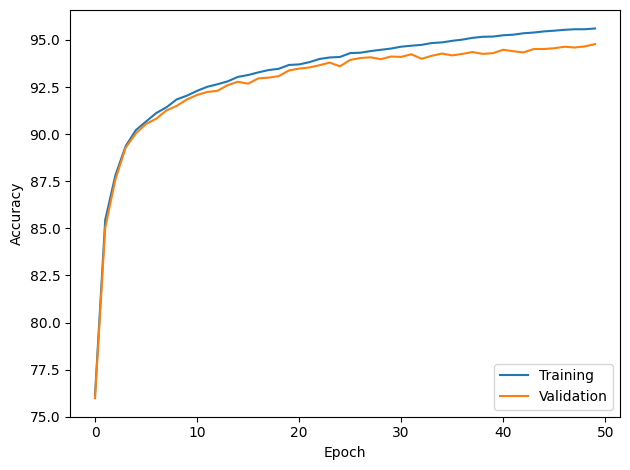

In [17]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc, label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [18]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)

print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 94.54%


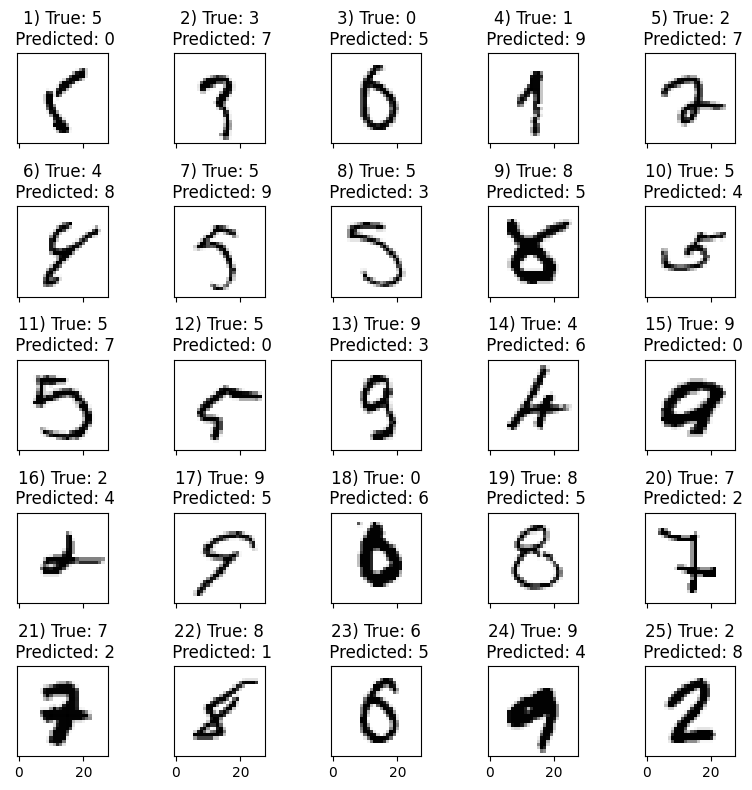

In [23]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

_, probas = model.forward(X_test_subset)

test_pred = np.argmax(probas, axis=1)
misclassified_images = \
        X_test_subset[y_test_subset != test_pred][:25]

misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

fig, ax = plt.subplots(ncols=5, nrows=5, sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')

    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')
    
ax[0].set_yticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()